# przygotowanie danych i importy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.model_selection as skm
from matplotlib.pyplot import subplots
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import PredictionErrorDisplay
from imblearn.over_sampling import RandomOverSampler
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             confusion_matrix,
                             ConfusionMatrixDisplay,
                             mean_squared_error)
from sklearn.ensemble import (RandomForestRegressor as RF,
                              GradientBoostingRegressor as GBR)

In [ ]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")
nr_gr = 3.8
r_k = 2025
np.random.seed(int(nr_gr*r_k))
q = data.shape
idx = np.random.permutation(q[0])
data = data.iloc[idx[0:5000],:]
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1366,35737,Male,1.08,0,0,No,children,Urban,86.09,19.5,Unknown,0
772,72547,Male,61.00,0,0,Yes,Private,Rural,55.26,33.2,Unknown,0
316,72214,Male,61.00,0,0,Yes,Self-employed,Urban,69.15,27.7,formerly smoked,0
3450,60088,Male,49.00,1,0,Yes,Self-employed,Rural,92.26,33.1,formerly smoked,0
468,28645,Female,38.00,1,0,Yes,Private,Urban,196.01,28.1,never smoked,0


In [ ]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,4802.000000,5000.000000
mean,36491.268200,43.300856,0.098200,0.054200,105.945338,28.915473,0.048800
std,21206.828898,22.587392,0.297615,0.226435,45.113828,7.838722,0.215471
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17660.750000,25.000000,0.000000,0.000000,77.190000,23.600000,0.000000
50%,36898.500000,45.000000,0.000000,0.000000,91.820000,28.100000,0.000000
75%,54770.750000,61.000000,0.000000,0.000000,113.862500,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,267.760000,97.600000,1.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 1366 to 1795
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   age                5000 non-null   float64
 3   hypertension       5000 non-null   int64  
 4   heart_disease      5000 non-null   int64  
 5   ever_married       5000 non-null   object 
 6   work_type          5000 non-null   object 
 7   Residence_type     5000 non-null   object 
 8   avg_glucose_level  5000 non-null   float64
 9   bmi                4802 non-null   float64
 10  smoking_status     5000 non-null   object 
 11  stroke             5000 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 507.8+ KB


In [ ]:
data=data.drop('id', axis = 1)

In [ ]:
data.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5000.000000,5000.000000,5000.000000,5000.000000,4802.000000,5000.000000
mean,43.300856,0.098200,0.054200,105.945338,28.915473,0.048800
std,22.587392,0.297615,0.226435,45.113828,7.838722,0.215471
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.190000,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.820000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.862500,33.100000,0.000000
max,82.000000,1.000000,1.000000,267.760000,97.600000,1.000000


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,198
smoking_status,0


In [ ]:
data = data.dropna(axis = 0)

In [ ]:
data.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
data2 = pd.DataFrame()

In [ ]:
data2['age'] = data['age']
data2['avg_glucose_level'] = data['avg_glucose_level']
data2['heart_disease'] = data['heart_disease']
data2['hypertension'] = data['hypertension']
data2['bmi'] = data['bmi']
data2['stroke'] = data['stroke']

In [ ]:
data.nunique()

,0
gender,3
age,104
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3779
bmi,414
smoking_status,4


In [ ]:
data['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
data['work_type'].unique()

array(['children', 'Private', 'Self-employed', 'Govt_job', 'Never_worked'],
      dtype=object)

In [ ]:
data['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [ ]:
data['smoking_status'].unique()

array(['Unknown', 'formerly smoked', 'never smoked', 'smokes'],
      dtype=object)

In [ ]:
data2['ever_married'] = np.int64(data['ever_married']=='Yes')

In [ ]:
data2['urban_residence'] = np.int64(data['Residence_type']=='Urban')

In [ ]:
data2['work_type_Private'] = np.int64(data['work_type']=='Private')
data2['work_type_Self_emp'] = np.int64(data['work_type']=='Self-employed')
data2['work_type_Govt_job'] = np.int64(data['work_type']=='Govt_job')
data2['work_type_Children'] = np.int64(data['work_type']=='children')
data2['work_type_Never_worked'] = np.int64(data['work_type']=='Never_worked')

In [ ]:
data2['smoking_status_unknown'] = np.int64(data['smoking_status']=='Unknown')
data2['smoking_status_formerly_smoked'] = np.int64(data['smoking_status']=='formerly smoked')
data2['smoking_status_never_smoked'] = np.int64(data['smoking_status']=='never smoked')
data2['smoking_status_smoked'] = np.int64(data['smoking_status']=='smokes')

In [ ]:
data2['gender_female'] = np.int64(data['gender']=='Female')
data2['gender_male'] = np.int64(data['gender']=='Male')
data2['gender_other'] = np.int64(data['gender']=='Other')

In [ ]:
data2.describe()

,age,avg_glucose_level,heart_disease,hypertension,bmi,stroke,ever_married,urban_residence,work_type_Private,work_type_Self_emp,work_type_Govt_job,work_type_Children,work_type_Never_worked,smoking_status_unknown,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smoked,gender_female,gender_male,gender_other
count,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000,4802.000000
mean,42.934902,105.110202,0.049771,0.092670,28.915473,0.042482,0.654519,0.506664,0.572470,0.159100,0.128072,0.135985,0.004373,0.301333,0.170554,0.377343,0.150771,0.588297,0.411495,0.000208
std,22.530317,44.253623,0.217494,0.289999,7.838722,0.201708,0.475574,0.500008,0.494772,0.365808,0.334204,0.342808,0.065992,0.458885,0.376158,0.484772,0.357862,0.492193,0.492156,0.014431
min,0.080000,55.120000,0.000000,0.000000,10.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,76.995000,0.000000,0.000000,23.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,44.000000,91.620000,0.000000,0.000000,28.100000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
75%,60.000000,113.325000,0.000000,0.000000,33.100000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000
max,82.000000,267.760000,1.000000,1.000000,97.600000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
data2.head()

,age,avg_glucose_level,heart_disease,hypertension,bmi,stroke,ever_married,urban_residence,work_type_Private,work_type_Self_emp,work_type_Govt_job,work_type_Children,work_type_Never_worked,smoking_status_unknown,smoking_status_formerly_smoked,smoking_status_never_smoked,smoking_status_smoked,gender_female,gender_male,gender_other
1366,1.08,86.09,0,0,19.5,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0
772,61.00,55.26,0,0,33.2,0,1,0,1,0,0,0,0,1,0,0,0,0,1,0
316,61.00,69.15,0,0,27.7,0,1,1,0,1,0,0,0,0,1,0,0,0,1,0
3450,49.00,92.26,0,1,33.1,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0
468,38.00,196.01,0,1,28.1,0,1,1,1,0,0,0,0,0,0,1,0,1,0,0


In [ ]:
data2.columns[5]

'stroke'

# uczenie oryginalne na stroku

In [ ]:
X = data2.drop(columns=data2.columns[5])  #strok w szóstej kolumnie
y = data2.iloc[:, 5]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 1)
dt = DTC(criterion='entropy', max_depth=5, random_state=1)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.963579604578564


Optymalna wartość max_depth: 1
Maksymalna dokładność w kroswalidacji: 0.9555


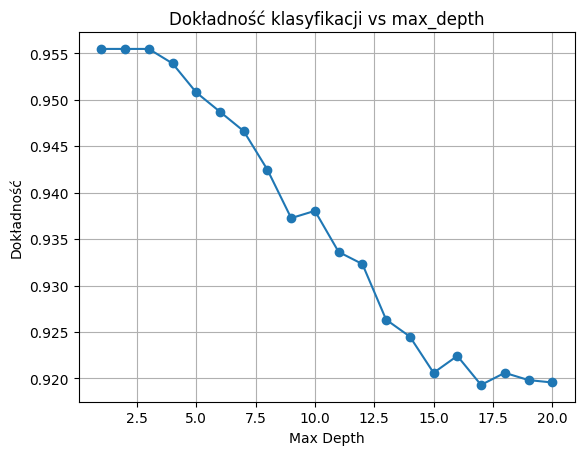

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

depths = range(1, 21)
cv_scores = []

for d in depths:
    dt = DTC(criterion='entropy', max_depth=d, random_state=1)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

optimal_depth = depths[np.argmax(cv_scores)]
print(f'Optymalna wartość max_depth: {optimal_depth}')
print(f'Maksymalna dokładność w kroswalidacji: {max(cv_scores):.4f}')

plt.plot(depths, cv_scores, marker='o', linestyle='-')
plt.xlabel('Max Depth')
plt.ylabel('Dokładność')
plt.title('Dokładność klasyfikacji vs max_depth')
plt.grid()
plt.show()

In [ ]:
for d in range(1, 10):
    dt = DTC(criterion='entropy', max_depth=d, random_state=1)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'max_depth={d}, Accuracy (train-test split): {acc:.4f}')

max_depth=1, Accuracy (train-test split): 0.9657
max_depth=2, Accuracy (train-test split): 0.9657
max_depth=3, Accuracy (train-test split): 0.9657
max_depth=4, Accuracy (train-test split): 0.9605
max_depth=5, Accuracy (train-test split): 0.9636
max_depth=6, Accuracy (train-test split): 0.9615
max_depth=7, Accuracy (train-test split): 0.9605
max_depth=8, Accuracy (train-test split): 0.9625
max_depth=9, Accuracy (train-test split): 0.9605


In [ ]:
for d in range(1, 10):
    dt = DTC(criterion='entropy', max_depth=d, random_state=1)
    scores = cross_val_score(dt, X_train, y_train, cv=5)
    print(f'max_depth={d}, CV Accuracy: {scores.mean():.4f}')

max_depth=1, CV Accuracy: 0.9555
max_depth=2, CV Accuracy: 0.9555
max_depth=3, CV Accuracy: 0.9555
max_depth=4, CV Accuracy: 0.9539
max_depth=5, CV Accuracy: 0.9508
max_depth=6, CV Accuracy: 0.9487
max_depth=7, CV Accuracy: 0.9466
max_depth=8, CV Accuracy: 0.9425
max_depth=9, CV Accuracy: 0.9373


Dokładność na zbiorze treningowym: 0.9555
Dokładność na zbiorze testowym: 0.9657


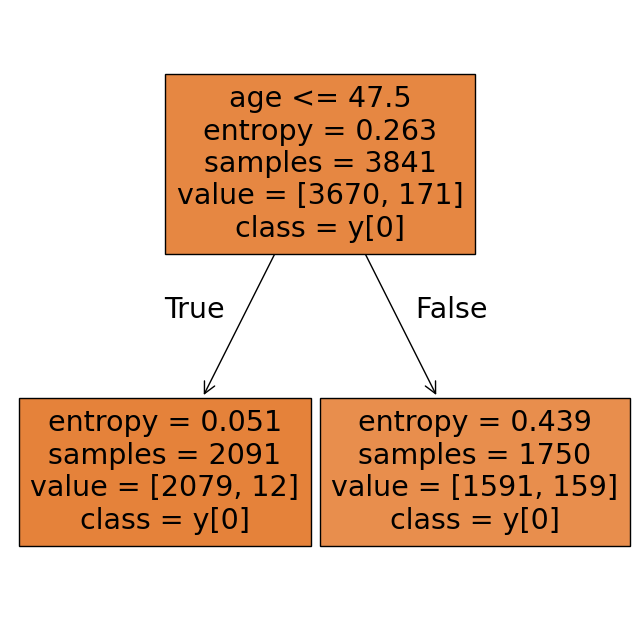

|--- age <= 47.50
|   |--- weights: [2079.00, 12.00] class: 0
|--- age >  47.50
|   |--- weights: [1591.00, 159.00] class: 0



In [ ]:
optimal_depth = 1  #stworzę też dla 2 i 3
dt = DTC(criterion='entropy', max_depth=optimal_depth, random_state=1)
dt.fit(X_train, y_train)

train_accuracy = accuracy_score(y_train, dt.predict(X_train))
test_accuracy = accuracy_score(y_test, dt.predict(X_test))

print(f'Dokładność na zbiorze treningowym: {train_accuracy:.4f}')
print(f'Dokładność na zbiorze testowym: {test_accuracy:.4f}')

fig, ax = plt.subplots(figsize=(8, 8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True, ax=ax)
plt.show()

rules = export_text(dt, feature_names=list(X.columns), show_weights=True)
print(rules)

Wynika, ze najwazniejsza cecha pozwalajaca okreslic ryzyko udaru to wiek. dopiero na glebokosci 3 dochodzi govt job, bmi i avg glucose lvl. do dalszej pracy wybieram jednak najmniej skomplikowabe drzewo, skoro maja taka sama dokladnosc.

Dokładność na zbiorze treningowym: 0.9555
Dokładność na zbiorze testowym: 0.9657


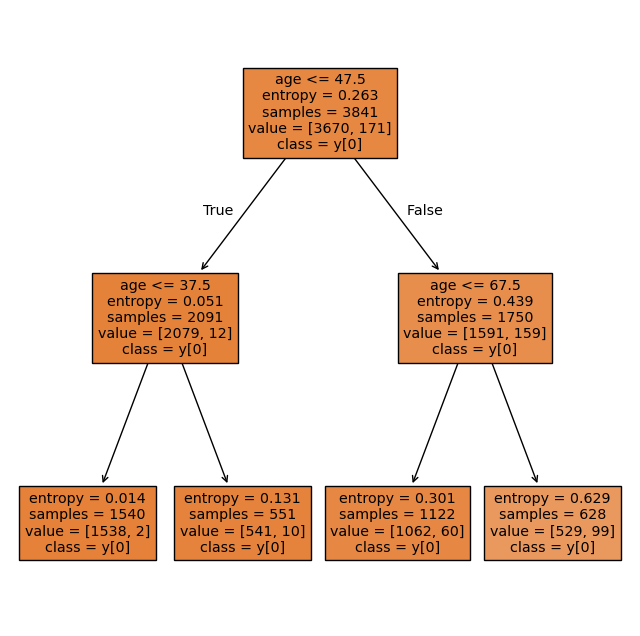

|--- age <= 47.50
|   |--- age <= 37.50
|   |   |--- weights: [1538.00, 2.00] class: 0
|   |--- age >  37.50
|   |   |--- weights: [541.00, 10.00] class: 0
|--- age >  47.50
|   |--- age <= 67.50
|   |   |--- weights: [1062.00, 60.00] class: 0
|   |--- age >  67.50
|   |   |--- weights: [529.00, 99.00] class: 0



In [ ]:
# Uczenie drzewa z optymalnym max_depth
optimal_depth = 2  # Możesz zmienić na 2 lub 3, jeśli chcesz
dt = DTC(criterion='entropy', max_depth=optimal_depth, random_state=1)
dt.fit(X_train, y_train)

# Obliczanie dokładności
train_accuracy = accuracy_score(y_train, dt.predict(X_train))
test_accuracy = accuracy_score(y_test, dt.predict(X_test))

print(f'Dokładność na zbiorze treningowym: {train_accuracy:.4f}')
print(f'Dokładność na zbiorze testowym: {test_accuracy:.4f}')

# Rysowanie drzewa
fig, ax = plt.subplots(figsize=(8, 8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True, ax=ax)
plt.show()

# Wypisanie reguł decyzyjnych
rules = export_text(dt, feature_names=list(X.columns), show_weights=True)
print(rules)

Dokładność na zbiorze treningowym: 0.9555
Dokładność na zbiorze testowym: 0.9657


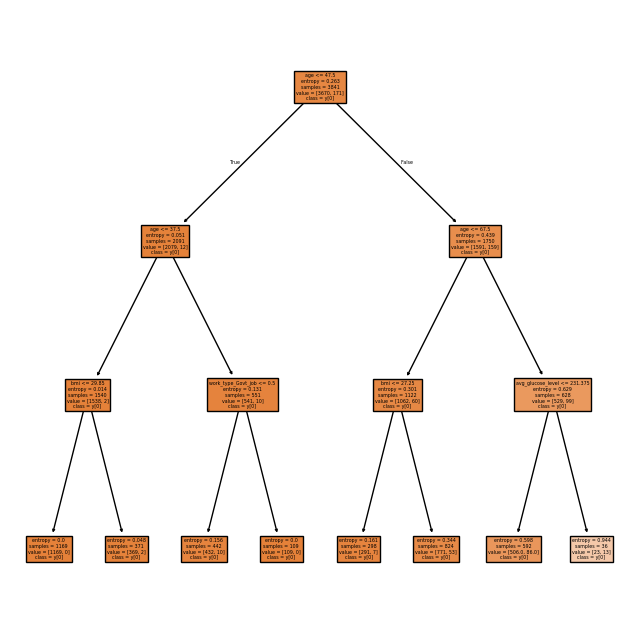

|--- age <= 47.50
|   |--- age <= 37.50
|   |   |--- bmi <= 29.85
|   |   |   |--- weights: [1169.00, 0.00] class: 0
|   |   |--- bmi >  29.85
|   |   |   |--- weights: [369.00, 2.00] class: 0
|   |--- age >  37.50
|   |   |--- work_type_Govt_job <= 0.50
|   |   |   |--- weights: [432.00, 10.00] class: 0
|   |   |--- work_type_Govt_job >  0.50
|   |   |   |--- weights: [109.00, 0.00] class: 0
|--- age >  47.50
|   |--- age <= 67.50
|   |   |--- bmi <= 27.25
|   |   |   |--- weights: [291.00, 7.00] class: 0
|   |   |--- bmi >  27.25
|   |   |   |--- weights: [771.00, 53.00] class: 0
|   |--- age >  67.50
|   |   |--- avg_glucose_level <= 231.38
|   |   |   |--- weights: [506.00, 86.00] class: 0
|   |   |--- avg_glucose_level >  231.38
|   |   |   |--- weights: [23.00, 13.00] class: 0



In [ ]:
# Uczenie drzewa z optymalnym max_depth
optimal_depth = 3  # Możesz zmienić na 2 lub 3, jeśli chcesz
dt = DTC(criterion='entropy', max_depth=optimal_depth, random_state=1)
dt.fit(X_train, y_train)

# Obliczanie dokładności
train_accuracy = accuracy_score(y_train, dt.predict(X_train))
test_accuracy = accuracy_score(y_test, dt.predict(X_test))

print(f'Dokładność na zbiorze treningowym: {train_accuracy:.4f}')
print(f'Dokładność na zbiorze testowym: {test_accuracy:.4f}')

# Rysowanie drzewa
fig, ax = plt.subplots(figsize=(8, 8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True, ax=ax)
plt.show()

# Wypisanie reguł decyzyjnych
rules = export_text(dt, feature_names=list(X.columns), show_weights=True)
print(rules)

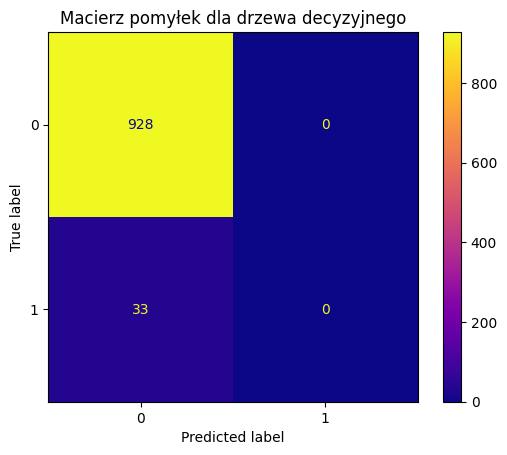

In [ ]:
cm = confusion_matrix(y_test, dt.predict(X_test), labels=dt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap="plasma")
plt.title("Macierz pomyłek dla drzewa decyzyjnego")
plt.show()

# uczenie po oversamplingu

In [ ]:
ros = RandomOverSampler(random_state=1)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

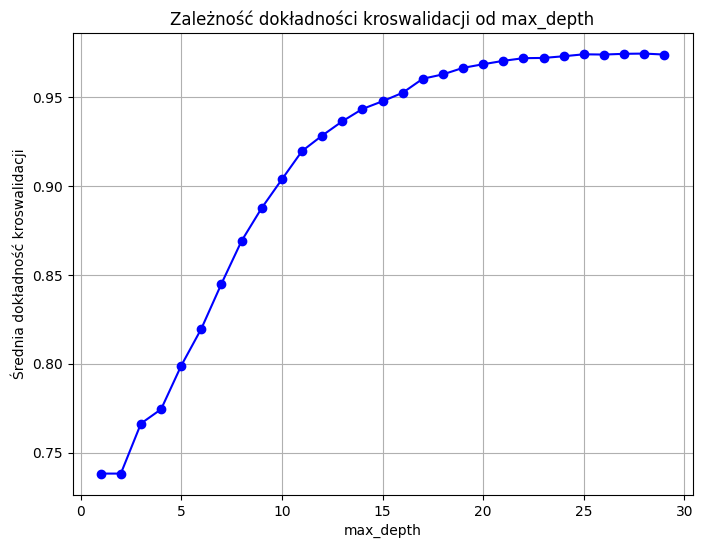

Optymalna wartość max_depth: 28


In [ ]:
depths = range(1, 30)
cv_accuracies = []

for depth in depths:
    dt = DTC(criterion='entropy', max_depth=depth, random_state=1)
    cv_scores = cross_val_score(dt, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    cv_accuracies.append(np.mean(cv_scores))

plt.figure(figsize=(8, 6))
plt.plot(depths, cv_accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('max_depth')
plt.ylabel('Średnia dokładność kroswalidacji')
plt.title('Zależność dokładności kroswalidacji od max_depth')
plt.grid(True)
plt.show()

optimal_depth = depths[np.argmax(cv_accuracies)]
print(f'Optymalna wartość max_depth: {optimal_depth}')

In [ ]:
dt = DTC(criterion='entropy', max_depth=optimal_depth, random_state=1)
dt.fit(X_train_resampled, y_train_resampled)

train_accuracy = accuracy_score(y_train_resampled, dt.predict(X_train_resampled))
test_accuracy = accuracy_score(y_test, dt.predict(X_test))

print(f'Dokładność na zbiorze treningowym: {train_accuracy:.4f}')
print(f'Dokładność na zbiorze testowym: {test_accuracy:.4f}')

Dokładność na zbiorze treningowym: 1.0000
Dokładność na zbiorze testowym: 0.9272


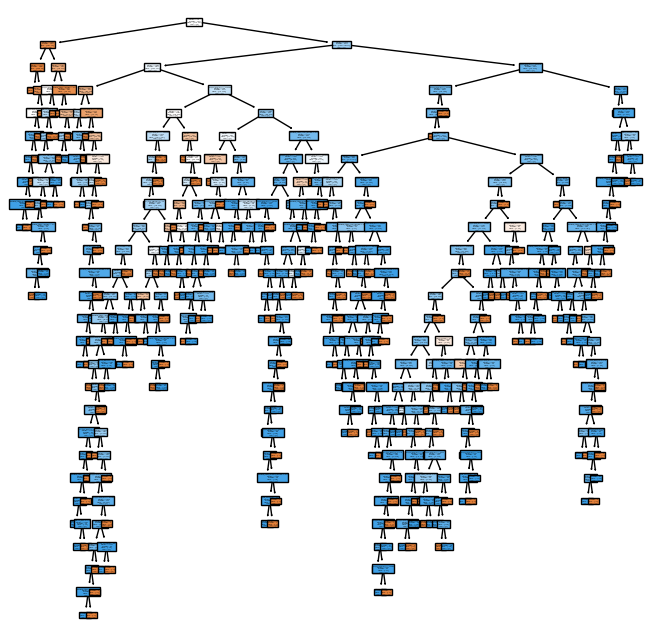

|--- age <= 44.50
|   |--- age <= 37.50
|   |   |--- bmi <= 29.85
|   |   |   |--- weights: [1169.00, 0.00] class: 0
|   |   |--- bmi >  29.85
|   |   |   |--- bmi <= 30.95
|   |   |   |   |--- avg_glucose_level <= 76.34
|   |   |   |   |   |--- urban_residence <= 0.50
|   |   |   |   |   |   |--- age <= 34.00
|   |   |   |   |   |   |   |--- work_type_Self_emp <= 0.50
|   |   |   |   |   |   |   |   |--- smoking_status_formerly_smoked <= 0.50
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 42.00] class: 1
|   |   |   |   |   |   |   |   |--- smoking_status_formerly_smoked >  0.50
|   |   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- work_type_Self_emp >  0.50
|   |   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |   |--- age >  34.00
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: 0
|   |   |   |   |   |--- urban_residence >  0.50
|   |   |   |   |   |   |--- weights: [4.00, 0.0

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True, ax=ax)
plt.show()

rules = export_text(dt, feature_names=list(X.columns), show_weights=True)
print(rules)

mimo, ze drzewo jest teraz glebsze, to piwersza decyzja jest nadal wiek. potem, podobnie jak w drzewie z depth 3, pojawiaja sie work type i avg glucose lvl.

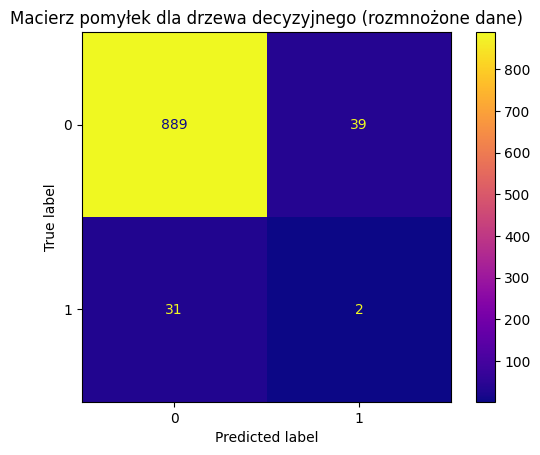

In [ ]:
cm = confusion_matrix(y_test, dt.predict(X_test), labels=dt.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap="plasma")
plt.title("Macierz pomyłek dla drzewa decyzyjnego (rozmnożone dane)")
plt.show()

In [ ]:
# Uczenie modelu bez oversamplingu (na oryginalnych danych)
dt_original = DTC(criterion='entropy', max_depth=optimal_depth, random_state=1)
dt_original.fit(X_train, y_train)

# Obliczanie dokładności bez oversamplingu
train_accuracy_original = accuracy_score(y_train, dt_original.predict(X_train))
test_accuracy_original = accuracy_score(y_test, dt_original.predict(X_test))

print(f'Dokładność na zbiorze treningowym (oryginalne dane): {train_accuracy_original:.4f}')
print(f'Dokładność na zbiorze testowym (oryginalne dane): {test_accuracy_original:.4f}')

Dokładność na zbiorze treningowym (oryginalne dane): 0.9578
Dokładność na zbiorze testowym (oryginalne dane): 0.9636


# bmi


In [ ]:
X = data2.drop(columns=['bmi'])
y = data2['bmi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
max_depths = range(1, 21)
cw = np.zeros(len(max_depths))

for i, depth in enumerate(max_depths):
    dt = DTR(criterion='squared_error', max_depth=depth, random_state=1)
    cw[i] = -cross_val_score(dt, X_train, y_train, cv=10, scoring='neg_mean_squared_error').mean()

optimal_depth = max_depths[np.argmin(cw)]
optimal_depth, min(cw)


(4, np.float64(46.68324377722213))

|--- work_type_Children <= 0.50
|   |--- avg_glucose_level <= 182.88
|   |   |--- age <= 29.50
|   |   |   |--- hypertension <= 0.50
|   |   |   |   |--- value: [27.25]
|   |   |   |--- hypertension >  0.50
|   |   |   |   |--- value: [52.19]
|   |   |--- age >  29.50
|   |   |   |--- age <= 66.50
|   |   |   |   |--- value: [30.84]
|   |   |   |--- age >  66.50
|   |   |   |   |--- value: [28.30]
|   |--- avg_glucose_level >  182.88
|   |   |--- age <= 66.50
|   |   |   |--- age <= 33.50
|   |   |   |   |--- value: [29.32]
|   |   |   |--- age >  33.50
|   |   |   |   |--- value: [36.23]
|   |   |--- age >  66.50
|   |   |   |--- age <= 74.50
|   |   |   |   |--- value: [33.11]
|   |   |   |--- age >  74.50
|   |   |   |   |--- value: [30.21]
|--- work_type_Children >  0.50
|   |--- age <= 10.50
|   |   |--- heart_disease <= 0.50
|   |   |   |--- age <= 6.50
|   |   |   |   |--- value: [18.56]
|   |   |   |--- age >  6.50
|   |   |   |   |--- value: [19.62]
|   |   |--- heart_disease 

46.256048883454106

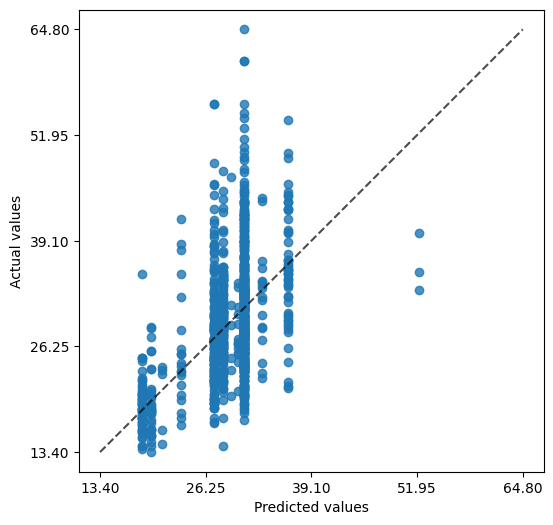

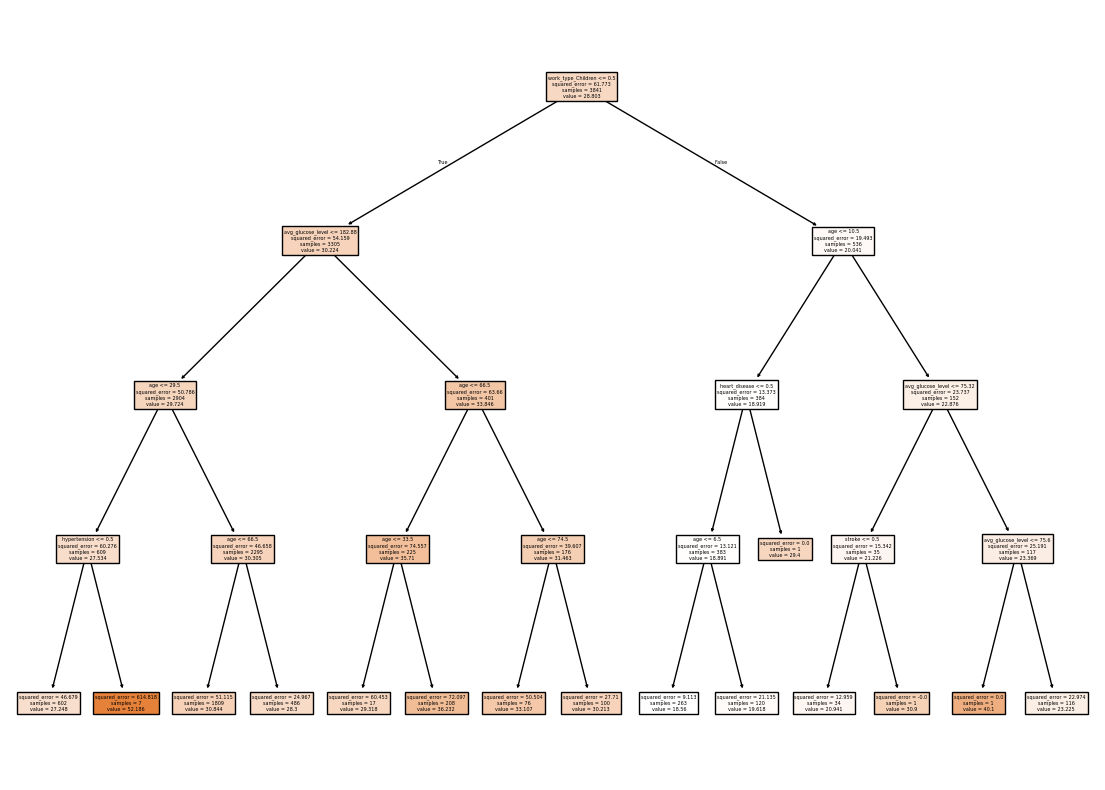

In [ ]:
dt = DTR(criterion='squared_error', max_depth=optimal_depth, random_state=1)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

ax = subplots(figsize=(6, 6))[1]
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    ax=ax,
    random_state=0,
)

ax = subplots(figsize=(14, 10))[1]
plot_tree(dt, feature_names=X.columns, filled=True, ax=ax)

print(export_text(dt, feature_names=list(X.columns), show_weights=True))

mse

decyzje - czy jest sie dzieckiem, potem wiek i avg glucose lvl.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
max_features_range = range(1, X_train.shape[1] + 1)

cv_results = []

for max_features in max_features_range:
    rf = RandomForestRegressor(
        criterion='squared_error',
        max_depth=optimal_depth,
        max_features=max_features,
        random_state=1
    )
    scores = cross_val_score(rf, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    cv_results.append(-scores.mean())

optimal_max_features = max_features_range[np.argmin(cv_results)]

print(f"Optymalna wartość max_features: {optimal_max_features}")

Optymalna wartość max_features: 12


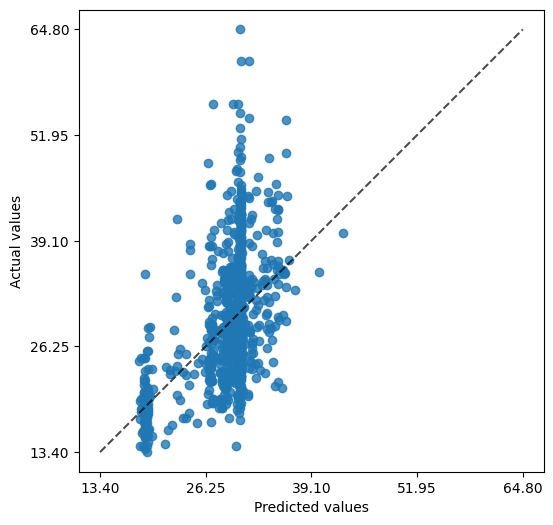

Optymalna wartość max_features: 12
Błąd średniokwadratowy (MSE) dla modelu RandomForest: 45.073871079053724


In [ ]:
rf_optimal = RandomForestRegressor(
    criterion='squared_error',
    max_depth=optimal_depth,
    max_features=optimal_max_features,
    random_state=1
)
rf_optimal.fit(X_train, y_train)

y_pred_rf = rf_optimal.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 6))
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_rf,
    kind="actual_vs_predicted",
    ax=ax,
    random_state=0,
)
plt.show()

print(f"Optymalna wartość max_features: {optimal_max_features}")
print(f"Błąd średniokwadratowy (MSE) dla modelu RandomForest: {mse_rf}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
learning_rate_range = np.linspace(0.01, 0.1, 10)

cv_results = []

for learning_rate in learning_rate_range:
    gb = GradientBoostingRegressor(
        max_depth=optimal_depth,
        learning_rate=learning_rate,
        random_state=1
    )
    scores = cross_val_score(gb, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    cv_results.append(-scores.mean())

optimal_learning_rate = learning_rate_range[np.argmin(cv_results)]

print(f"Optymalna wartość learning_rate: {optimal_learning_rate}")

Optymalna wartość learning_rate: 0.020000000000000004


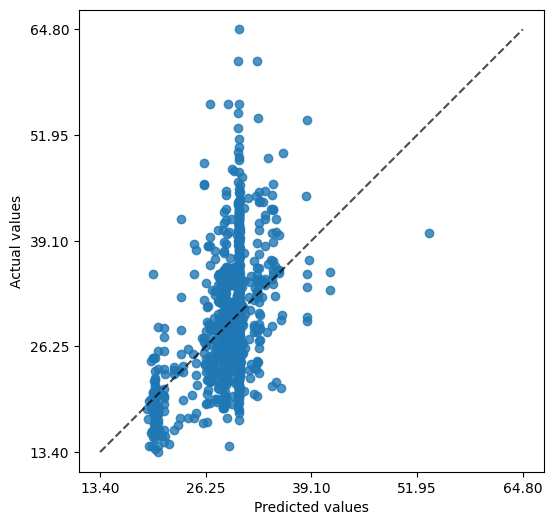

Optymalna wartość learning_rate: 0.020000000000000004
Błąd średniokwadratowy (MSE) dla modelu GradientBoosting: 45.42204003088785


In [ ]:
gb_optimal = GradientBoostingRegressor(
    max_depth=optimal_depth,
    learning_rate=optimal_learning_rate,
    random_state=1
)
gb_optimal.fit(X_train, y_train)

y_pred_gb = gb_optimal.predict(X_test)
mse_gb = mean_squared_error(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 6))
PredictionErrorDisplay.from_predictions(
    y_true=y_test,
    y_pred=y_pred_gb,
    kind="actual_vs_predicted",
    ax=ax,
    random_state=0,
)
plt.show()

print(f"Optymalna wartość learning_rate: {optimal_learning_rate}")
print(f"Błąd średniokwadratowy (MSE) dla modelu GradientBoosting: {mse_gb}")

In [ ]:
print("Porównanie wyników:")
print(f"DecisionTreeRegressor MSE: {mse}")
print(f"RandomForestRegressor MSE: {mse_rf}")
print(f"GradientBoostingRegressor MSE: {mse_gb}")

Porównanie wyników:
DecisionTreeRegressor MSE: 46.256048883454106
RandomForestRegressor MSE: 45.073871079053724
GradientBoostingRegressor MSE: 45.42204003088785


wszystkie trzy metody daja slabe wyniki, z czego mozna wnioskowac, ze z danych nie da sie dobrze klasyfikowac bmi. wyniki sa podobne do siebie, nie nastepuje poprawa. wykresy tez sa podobne.

wnioski końcowe:

dane nie pozwalaja na dobra klasyfikacje bmi metoda drzew decyzyjnych.